In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

c:\Users\15195\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path(
    r"C:\Users\15195\Desktop\coding part\dataset preparation"
)

household_features = pd.read_csv('C:/Users/15195/Desktop/coding part/dataset preparation/household_features_for_clustering.csv')

print(household_features.shape)
print(household_features.columns.tolist())

(2500, 18)
['household_key', 'recency', 'frequency', 'monetary', 'total_quantity', 'unique_products', 'category_diversity', 'first_purchase_day', 'last_purchase_day', 'average_basket_value', 'average_basket_size', 'customer_lifetime_days', 'total_retail_discount', 'total_coupon_discount', 'total_coupon_match_discount', 'total_discount', 'discount_ratio', 'coupon_discount_ratio']


In [3]:
cluster_variables = [
    "recency",
    "frequency",
    "monetary",
    "total_quantity",
    "average_basket_size",
    "category_diversity",
]

missing_columns = [
    col for col in cluster_variables
    if col not in household_features.columns
]

if missing_columns:
    raise ValueError(
        f"Missing clustering variables: {missing_columns}"
    )

print("All clustering variables are available.")

All clustering variables are available.


In [4]:
# Handling missing and infinite values 
# First, convert the positive and negative infinities to missing values, and then fill them in with the median.
# This is because the median is less susceptible to the influence of extreme values compared to the mean.
X = household_features[cluster_variables].copy()

X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.median())

print("Missing values after cleaning:")
print(X.isna().sum())

Missing values after cleaning:
recency                0
frequency              0
monetary               0
total_quantity         0
average_basket_size    0
category_diversity     0
dtype: int64


In [5]:
# Handling highly skewed variables
log_variables = [
    "frequency",
    "monetary",
    "average_basket_size",
    "category_diversity",
]

for col in log_variables:
    if (X[col] >= 0).all():
        X[col] = np.log1p(X[col])

In [6]:
# Apply trimming to extreme values
for col in cluster_variables:
    lower = X[col].quantile(0.01)
    upper = X[col].quantile(0.99)
    X[col] = X[col].clip(lower=lower, upper=upper)

In [7]:
# Z-score normalization
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Verify the standardized results
scaled_check = pd.DataFrame(
    X_scaled,
    columns=cluster_variables
)

print(scaled_check.mean().round(4))
print(scaled_check.std(ddof=0).round(4))

recency               -0.0
frequency              0.0
monetary              -0.0
total_quantity        -0.0
average_basket_size    0.0
category_diversity    -0.0
dtype: float64
recency                1.0
frequency              1.0
monetary               1.0
total_quantity         1.0
average_basket_size    1.0
category_diversity     1.0
dtype: float64


In [8]:
# Test K=4 to K=6
# This portion does not immediately determine the value of k; instead, it compares different values of k to select the most suitable one
k_results = []

for k in range(4, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    cluster_labels = model.fit_predict(X_scaled)

    silhouette = silhouette_score(
        X_scaled,
        cluster_labels
    )

    k_results.append({
        "k": k,
        "wcss": model.inertia_,
        "silhouette_score": silhouette
    })

k_results = pd.DataFrame(k_results)

print(k_results)

   k         wcss  silhouette_score
0  4  6200.347607          0.328891
1  5  5178.677523          0.276700
2  6  4405.485752          0.276064


In [9]:
# Save the assessment results for K values 4 to 6
k_results.to_csv(
    r"C:\Users\15195\Desktop\kmeans_k_selection_results(4-6).csv",
    index=False
)

print("Saved kmeans_k_selection_results.csv(4-6)")

Saved kmeans_k_selection_results.csv(4-6)


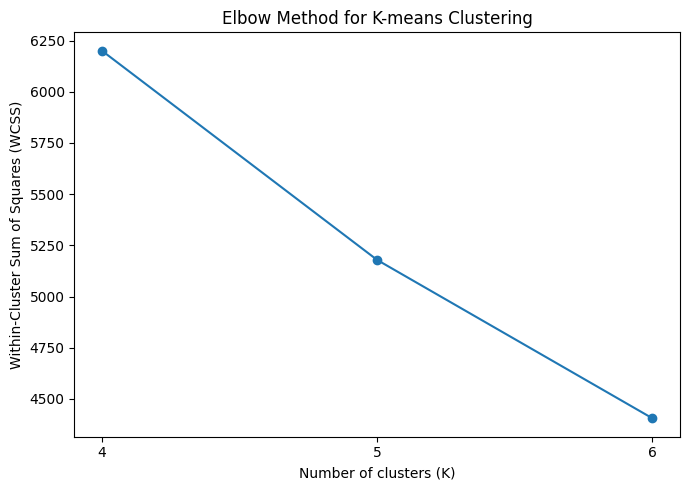

In [10]:
# Draw the Elbow Method diagram
plt.figure(figsize=(7, 5))

plt.plot(
    k_results["k"],
    k_results["wcss"],
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for K-means Clustering")
plt.xticks(k_results["k"])
plt.tight_layout()
plt.show()

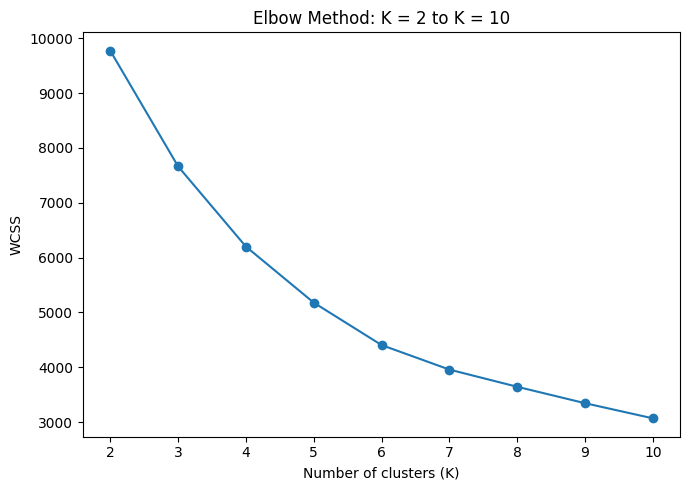

In [11]:
# Since a turning point needs to be observed, the range of the k value was expanded (from 2 to 10)
elbow_results = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_scaled)

    elbow_results.append({
        "k": k,
        "wcss": model.inertia_
    })

elbow_results = pd.DataFrame(elbow_results)

# Create the corresponding image
plt.figure(figsize=(7, 5))

plt.plot(
    elbow_results["k"],
    elbow_results["wcss"],
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method: K = 2 to K = 10")
plt.xticks(elbow_results["k"])
plt.tight_layout()
plt.show()

In [12]:
# Compare the cluster sizes for each K
cluster_size_results = []

for k in range(3, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    size_table = pd.Series(labels).value_counts().sort_index()

    for cluster_id, size in size_table.items():
        cluster_size_results.append({
            "k": k,
            "cluster": cluster_id,
            "household_count": size,
            "household_share": size / len(labels)
        })

cluster_size_results = pd.DataFrame(cluster_size_results)

print(cluster_size_results)

    k  cluster  household_count  household_share
0   3        0              286           0.1144
1   3        1             1660           0.6640
2   3        2              554           0.2216
3   4        0              258           0.1032
4   4        1             1409           0.5636
5   4        2              104           0.0416
6   4        3              729           0.2916
7   5        0              817           0.3268
8   5        1              568           0.2272
9   5        2              243           0.0972
10  5        3              768           0.3072
11  5        4              104           0.0416
12  6        0              630           0.2520
13  6        1              603           0.2412
14  6        2              598           0.2392
15  6        3              217           0.0868
16  6        4               76           0.0304
17  6        5              376           0.1504


In [13]:
# Save the  for K values 3 to 6
cluster_size_results.to_csv(
    r"C:\Users\15195\Desktop\kmeans_cluster_size_comparison.csv",
    index=False
)

In [14]:
# Test K=3 to K=6
# This portion does not immediately determine the value of k; instead, it compares different values of k to select the most suitable one
k_results = []

for k in range(3, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    cluster_labels = model.fit_predict(X_scaled)

    silhouette = silhouette_score(
        X_scaled,
        cluster_labels
    )

    k_results.append({
        "k": k,
        "wcss": model.inertia_,
        "silhouette_score": silhouette
    })

k_results = pd.DataFrame(k_results)

print(k_results)

   k         wcss  silhouette_score
0  3  7662.000313          0.349319
1  4  6200.347607          0.328891
2  5  5178.677523          0.276700
3  6  4405.485752          0.276064


In [15]:
# Save the assessment results for K values 3 to 6
k_results.to_csv(
    r"C:\Users\15195\Desktop\kmeans_k_selection_results(3-6).csv",
    index=False
)

print("Saved kmeans_k_selection_results(3-6).csv")

Saved kmeans_k_selection_results(3-6).csv


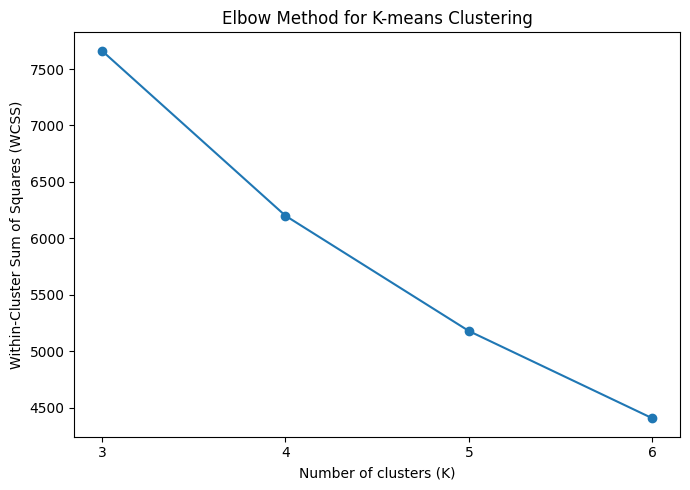

In [16]:
# Draw the Elbow Method diagram
plt.figure(figsize=(7, 5))

plt.plot(
    k_results["k"],
    k_results["wcss"],
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for K-means Clustering")
plt.xticks(k_results["k"])
plt.tight_layout()
plt.show()

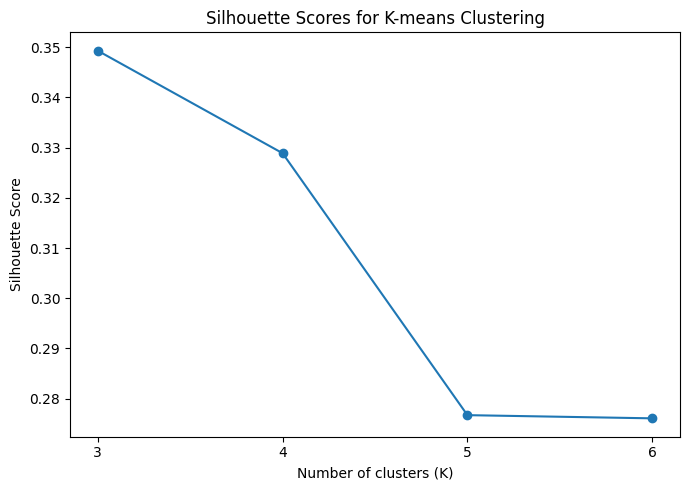

In [17]:
# Create a Silhouette Score diagram
plt.figure(figsize=(7, 5))

plt.plot(
    k_results["k"],
    k_results["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-means Clustering")
plt.xticks(k_results["k"])
plt.tight_layout()
plt.show()

In [18]:
# Compare the cluster sizes for each K
cluster_size_results = []

for k in range(3, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    size_table = pd.Series(labels).value_counts().sort_index()

    for cluster_id, size in size_table.items():
        cluster_size_results.append({
            "k": k,
            "cluster": cluster_id,
            "household_count": size,
            "household_share": size / len(labels)
        })

cluster_size_results = pd.DataFrame(cluster_size_results)

print(cluster_size_results)

#  Save the assessment results for K values 3 to 6
cluster_size_results.to_csv(
    r"C:\Users\15195\Desktop\kmeans_cluster_size_comparison (3-6).csv",
    index=False
)
print("kmeans_cluster_size_comparison (3-6).csv")

    k  cluster  household_count  household_share
0   3        0              286           0.1144
1   3        1             1660           0.6640
2   3        2              554           0.2216
3   4        0              258           0.1032
4   4        1             1409           0.5636
5   4        2              104           0.0416
6   4        3              729           0.2916
7   5        0              817           0.3268
8   5        1              568           0.2272
9   5        2              243           0.0972
10  5        3              768           0.3072
11  5        4              104           0.0416
12  6        0              630           0.2520
13  6        1              603           0.2412
14  6        2              598           0.2392
15  6        3              217           0.0868
16  6        4               76           0.0304
17  6        5              376           0.1504
kmeans_cluster_size_comparison (3-6).csv


In [19]:
# Select the final number of clusters by considering the silhouette score,
# elbow method, cluster size balance, and managerial interpretability.
final_k = 3

final_model = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

household_features["cluster"] = final_model.fit_predict(X_scaled)

final_cluster_sizes = (
    household_features["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="household_count")
)

final_cluster_sizes["household_share"] = (
    final_cluster_sizes["household_count"]
    / final_cluster_sizes["household_count"].sum()
)

print("Final K:", final_k)
print(final_cluster_sizes)

Final K: 3
   cluster  household_count  household_share
0        0              286           0.1144
1        1             1660           0.6640
2        2              554           0.2216


In [20]:
# Evaluate the stability of the final K=3 solution
# by repeating K-means with different random initialisations

stability_results = []
stability_labels = []

for seed in range(50):
    stability_model = KMeans(
        n_clusters=final_k,
        random_state=seed,
        n_init=20
    )

    labels = stability_model.fit_predict(X_scaled)

    stability_labels.append(labels)

    stability_results.append({
        "random_state": seed,
        "silhouette_score": silhouette_score(X_scaled, labels),
        "wcss": stability_model.inertia_,
        "smallest_cluster_size": np.sort(
            np.bincount(labels)
        )[0],
        "middle_cluster_size": np.sort(
            np.bincount(labels)
        )[1],
        "largest_cluster_size": np.sort(
            np.bincount(labels)
        )[2]
    })

stability_results = pd.DataFrame(stability_results)

print(stability_results.head())

   random_state  silhouette_score         wcss  smallest_cluster_size  \
0             0          0.349494  7662.109637                    288   
1             1          0.349319  7661.996859                    286   
2             2          0.349319  7662.012379                    286   
3             3          0.349319  7662.005361                    286   
4             4          0.349319  7662.012379                    286   

   middle_cluster_size  largest_cluster_size  
0                  554                  1658  
1                  554                  1660  
2                  554                  1660  
3                  554                  1660  
4                  554                  1660  


In [21]:
# Calculate pairwise Adjusted Rand Index (ARI)
# across the 50 repeated K-means solutions

ari_scores = []

for i in range(len(stability_labels)):
    for j in range(i + 1, len(stability_labels)):
        ari = adjusted_rand_score(
            stability_labels[i],
            stability_labels[j]
        )
        ari_scores.append(ari)

ari_scores = np.array(ari_scores)

print("Number of repeated runs:", len(stability_labels))
print("Mean ARI:", round(ari_scores.mean(), 4))
print("Median ARI:", round(np.median(ari_scores), 4))
print("Minimum ARI:", round(ari_scores.min(), 4))
print("Maximum ARI:", round(ari_scores.max(), 4))

Number of repeated runs: 50
Mean ARI: 0.9975
Median ARI: 0.9975
Minimum ARI: 0.989
Maximum ARI: 1.0


In [22]:
# Summarise the stability of silhouette scores and cluster sizes

stability_summary = pd.DataFrame({
    "Measure": [
        "Mean ARI",
        "Median ARI",
        "Minimum ARI",
        "Maximum ARI",
        "Mean Silhouette Score",
        "Silhouette Score SD",
        "Minimum Silhouette Score",
        "Maximum Silhouette Score",
        "Mean Smallest Cluster Size",
        "Mean Middle Cluster Size",
        "Mean Largest Cluster Size"
    ],
    "Value": [
        ari_scores.mean(),
        np.median(ari_scores),
        ari_scores.min(),
        ari_scores.max(),
        stability_results["silhouette_score"].mean(),
        stability_results["silhouette_score"].std(),
        stability_results["silhouette_score"].min(),
        stability_results["silhouette_score"].max(),
        stability_results["smallest_cluster_size"].mean(),
        stability_results["middle_cluster_size"].mean(),
        stability_results["largest_cluster_size"].mean()
    ]
})

print(stability_summary.round(4))

                       Measure      Value
0                     Mean ARI     0.9975
1                   Median ARI     0.9975
2                  Minimum ARI     0.9890
3                  Maximum ARI     1.0000
4        Mean Silhouette Score     0.3493
5          Silhouette Score SD     0.0002
6     Minimum Silhouette Score     0.3486
7     Maximum Silhouette Score     0.3495
8   Mean Smallest Cluster Size   286.9600
9     Mean Middle Cluster Size   554.4600
10   Mean Largest Cluster Size  1658.5800


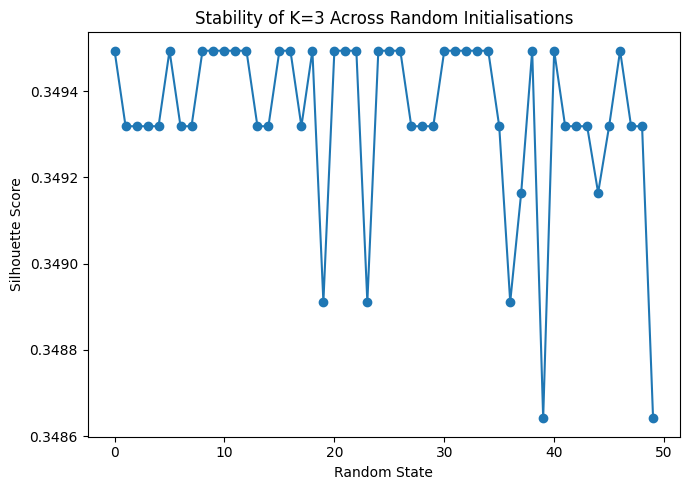

In [23]:
plt.figure(figsize=(7, 5))

plt.plot(
    stability_results["random_state"],
    stability_results["silhouette_score"],
    marker="o"
)

plt.xlabel("Random State")
plt.ylabel("Silhouette Score")
plt.title("Stability of K=3 Across Random Initialisations")
plt.tight_layout()
plt.show()

In [24]:
# Save the result (K=3)
household_features.to_csv(
    r"C:\Users\15195\Desktop\clustered_household_features (k=3).csv",
    index=False
)

final_cluster_sizes.to_csv(
    r"C:\Users\15195\Desktop\final_cluster_sizes(k=3).csv",
    index=False
)

print("Saved clustered_household_features.csv")
print("Saved final_cluster_sizes.csv")

Saved clustered_household_features.csv
Saved final_cluster_sizes.csv


In [25]:
# Calculate the average behavioral metrics for each segment
segment_profile = (
    household_features
    .groupby("cluster")
    .agg(
        household_count=("household_key", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        avg_basket_value=("average_basket_value", "mean"),
        avg_basket_size=("average_basket_size", "mean"),
        avg_category_diversity=("category_diversity", "mean"),
        avg_discount_ratio=("discount_ratio", "mean"),
        avg_customer_lifetime_days=("customer_lifetime_days", "mean")
    )
    .reset_index()
)

# Calculate the contribution of segment sales
segment_sales = (
    household_features
    .groupby("cluster")["monetary"]
    .sum()
    .reset_index(name="segment_total_sales")
)

segment_sales["segment_sales_share"] = (
    segment_sales["segment_total_sales"]
    / segment_sales["segment_total_sales"].sum()
)

segment_profile = segment_profile.merge(
    segment_sales,
    on="cluster",
    how="left"
)

# Display the calculated results
print(segment_profile.round(3))

   cluster  household_count  avg_recency  avg_frequency  avg_monetary  \
0        0              286        5.409        277.675      8910.702   
1        1             1660       12.291        109.909      3161.839   
2        2              554       75.785         26.390       469.944   

   avg_basket_value  avg_basket_size  avg_category_diversity  \
0            36.817           10.351                 169.668   
1            33.752           11.281                 126.907   
2            22.552            7.295                  53.249   

   avg_discount_ratio  avg_customer_lifetime_days  segment_total_sales  \
0               0.167                     636.780           2548460.83   
1               0.193                     634.307           5248653.32   
2               0.194                     566.143            260348.93   

   segment_sales_share  
0                0.316  
1                0.651  
2                0.032  


In [26]:
# Save the calculated results
segment_profile.to_csv(
    r"C:\Users\15195\Desktop\segment_profile.csv",
    index=False
)

print("Saved segment_profile.csv")

Saved segment_profile.csv


In [27]:
# Calculate the average behavioral metrics for each segment
segment_profile = (
    household_features
    .groupby("cluster")
    .agg(
        household_count=("household_key", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        avg_basket_value=("average_basket_value", "mean"),
        avg_basket_size=("average_basket_size", "mean"),
        avg_category_diversity=("category_diversity", "mean"),
        avg_discount_ratio=("discount_ratio", "mean"),
        avg_customer_lifetime_days=("customer_lifetime_days", "mean")
    )
    .reset_index()
)

# Calculate the household share
segment_profile["household_share"] = (
    segment_profile["household_count"]
    / segment_profile["household_count"].sum()
)

# Calculate the contribution of segment sales
segment_sales = (
    household_features
    .groupby("cluster")["monetary"]
    .sum()
    .reset_index(name="segment_total_sales")
)

segment_sales["segment_sales_share"] = (
    segment_sales["segment_total_sales"]
    / segment_sales["segment_total_sales"].sum()
)

segment_profile = segment_profile.merge(
    segment_sales,
    on="cluster",
    how="left"
)

# Display the calculated results
print(segment_profile.round(3))


   cluster  household_count  avg_recency  avg_frequency  avg_monetary  \
0        0              286        5.409        277.675      8910.702   
1        1             1660       12.291        109.909      3161.839   
2        2              554       75.785         26.390       469.944   

   avg_basket_value  avg_basket_size  avg_category_diversity  \
0            36.817           10.351                 169.668   
1            33.752           11.281                 126.907   
2            22.552            7.295                  53.249   

   avg_discount_ratio  avg_customer_lifetime_days  household_share  \
0               0.167                     636.780            0.114   
1               0.193                     634.307            0.664   
2               0.194                     566.143            0.222   

   segment_total_sales  segment_sales_share  
0           2548460.83                0.316  
1           5248653.32                0.651  
2            260348.93         

In [28]:
# Save the calculated results
segment_profile.to_csv(
    r"C:\Users\15195\Desktop\segment_profile.csv",
    index=False
)

print("Saved segment_profile.csv")

Saved segment_profile.csv


In [29]:
# Calculate the standardized cluster centroid
scaled_features = pd.DataFrame(
    X_scaled,
    columns=cluster_variables
)

scaled_features["cluster"] = household_features["cluster"].values

standardised_segment_profile = (
    scaled_features
    .groupby("cluster")[cluster_variables]
    .mean()
    .reset_index()
)

print(standardised_segment_profile.round(3))

   cluster  recency  frequency  monetary  total_quantity  average_basket_size  \
0        0   -0.366      1.235     1.268           2.351                0.098   
1        1   -0.230      0.204     0.258          -0.259                0.203   
2        2    0.877     -1.250    -1.429          -0.439               -0.660   

   category_diversity  
0               0.910  
1               0.331  
2              -1.462  


In [30]:
# Save the calculated results
standardised_segment_profile.to_csv(
    r"C:\Users\15195\Desktop\standardised_segment_profile.csv",
    index=False
)
print("standardised_segment_profile.csv")

standardised_segment_profile.csv


In [31]:
# Combine demographic statistics
# Read the table
transaction_demographic = pd.read_csv(
    r"C:\Users\15195\Desktop\coding part\dataset preparation\household_features_with_demographics.csv"
)

# Since a household can appear multiple times in a transaction-level table, let’s keep one row for each household initially
demographic_columns = [
    "household_key",
    "AGE_DESC",
    "MARITAL_STATUS_CODE",
    "INCOME_DESC",
    "HOMEOWNER_DESC",
    "HH_COMP_DESC",
    "HOUSEHOLD_SIZE_DESC",
    "KID_CATEGORY_DESC"
]

available_demographic_columns = [
    col for col in demographic_columns
    if col in transaction_demographic.columns
]

household_demographics = (
    transaction_demographic[available_demographic_columns]
    .drop_duplicates(subset=["household_key"])
)

# Merge the cluster labels into one
segment_demographics = household_demographics.merge(
    household_features[["household_key", "cluster"]],
    on="household_key",
    how="inner"
)

print(segment_demographics.head())


   household_key AGE_DESC MARITAL_STATUS_CODE INCOME_DESC HOMEOWNER_DESC  \
0              1      65+                   A      35-49K      Homeowner   
1              2      NaN                 NaN         NaN            NaN   
2              3      NaN                 NaN         NaN            NaN   
3              4      NaN                 NaN         NaN            NaN   
4              5      NaN                 NaN         NaN            NaN   

       HH_COMP_DESC HOUSEHOLD_SIZE_DESC KID_CATEGORY_DESC  cluster  
0  2 Adults No Kids                   2      None/Unknown        1  
1               NaN                 NaN               NaN        1  
2               NaN                 NaN               NaN        1  
3               NaN                 NaN               NaN        2  
4               NaN                 NaN               NaN        2  


In [28]:
# Save the  results
segment_demographics.to_csv(
    r"C:\Users\15195\Desktop\segment_demographics.csv",
    index=False
)
print("segment_demographics.csv")

segment_demographics.csv


In [32]:
# Calculate the demographic distribution of different segments
# Subject to income requirements
income_profile = pd.crosstab(
    segment_demographics["cluster"],
    segment_demographics["INCOME_DESC"],
    normalize="index"
) * 100

print(income_profile.round(2))

INCOME_DESC  100-124K  125-149K  15-24K  150-174K  175-199K  200-249K  25-34K  \
cluster                                                                         
0                6.67      7.62    5.71      6.19      1.90      0.00    8.57   
1                3.39      3.73   10.51      2.88      1.19      0.85   10.00   
2                0.00      0.00    0.00      0.00      0.00      0.00    0.00   

INCOME_DESC  250K+  35-49K  50-74K  75-99K  Under 15K  
cluster                                                
0             1.90   13.81   24.29   14.76       8.57  
1             1.19   24.07   23.90   11.02       7.29  
2             0.00  100.00    0.00    0.00       0.00  


In [33]:
# Save the  results
income_profile.to_csv(
    r"C:\Users\15195\Desktop\segment_income_profile.csv"
)
print("segment_income_profile.csv")

segment_income_profile.csv


In [34]:
# Based on the size of the household
household_size_profile = pd.crosstab(
    segment_demographics["cluster"],
    segment_demographics["HOUSEHOLD_SIZE_DESC"],
    normalize="index"
) * 100
print(household_size_profile.round(2))

HOUSEHOLD_SIZE_DESC       1      2      3     4    5+
cluster                                              
0                     31.43  38.10  12.38  9.05  9.05
1                     31.86  40.34  14.07  5.76  7.97
2                    100.00   0.00   0.00  0.00  0.00


In [35]:
# Save the  results
household_size_profile.to_csv(
    r"C:\Users\15195\Desktop\household_size_profile.csv"
)
print("household_size_profile.csv")

household_size_profile.csv


In [36]:
# Based on age
age_profile = pd.crosstab(
    segment_demographics["cluster"],
    segment_demographics["AGE_DESC"],
    normalize="index"
) * 100
print(age_profile.round(2))

AGE_DESC  19-24  25-34  35-44   45-54  55-64    65+
cluster                                            
0          3.81  17.62  31.43   35.24   6.67   5.24
1          6.44  17.80  21.69   36.10   7.63  10.34
2          0.00   0.00   0.00  100.00   0.00   0.00


In [37]:
# Save the  results
age_profile.to_csv(
    r"C:\Users\15195\Desktop\age_profile.csv"
)
print("age_profile.csv")

age_profile.csv


In [38]:
# Assuming there are children involved
kid_profile = pd.crosstab(
    segment_demographics["cluster"],
    segment_demographics["KID_CATEGORY_DESC"],
    normalize="index"
) * 100

print(kid_profile.round(2))

KID_CATEGORY_DESC      1     2    3+  None/Unknown
cluster                                           
0                  13.81  9.52  9.52         67.14
1                  14.41  6.78  8.31         70.51
2                   0.00  0.00  0.00        100.00


In [39]:
# Save the  results
kid_profile.to_csv(
    r"C:\Users\15195\Desktop\kid_profile.csv"
)
print("kid_profile.csv")

kid_profile.csv
